In [1]:
#Importing Libraries
import pandas as pd
from datasets import load_dataset
import matplotlib.pyplot as plt
import ast

#Loading Dataset
dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()

#Data Cleanup
df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])
df['job_skills'] = df['job_skills'].apply(lambda skill_list: ast.literal_eval(skill_list) if pd.notna(skill_list) else skill_list)

In [24]:
df['job_work_from_home'].value_counts()

job_work_from_home
False    716189
True      69552
Name: count, dtype: int64

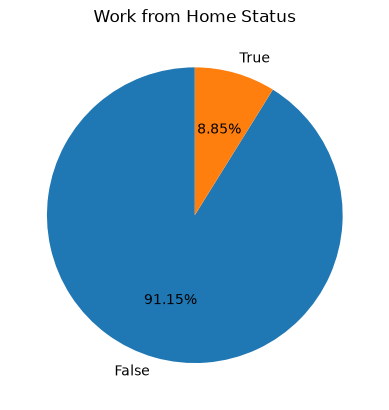

In [10]:
df['job_work_from_home'].value_counts().plot(kind='pie',startangle=90,autopct='%1.2f%%') #autopct= Auto Percent. % = format the text. int(1) is min. width of number left of deciaml. then after dot is maximum numbers after decimal. then f=float, then again %to format text, then % to add '%' symbol
plt.title('Work from Home Status')
plt.ylabel('')
plt.show()

In [ ]:
df[['job_work_from_home', 'job_no_degree_mention', 'job_health_insurance']]
#plotting all in subplots

,job_work_from_home,job_no_degree_mention,job_health_insurance
0,False,False,False
1,False,False,False
2,False,False,False
3,False,True,False
4,False,False,False
...,...,...,...
785736,False,False,False
785737,False,False,False
785738,False,False,False
785739,False,False,False


0 job_work_from_home Work from Home
1 job_no_degree_mention Job Degree Req.
2 job_health_insurance Health Insurance Offered


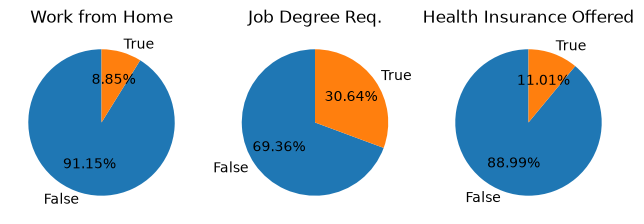

In [27]:
fig,ax = plt.subplots(1,3)

dict_column = {
    'job_work_from_home': 'Work from Home',
    'job_no_degree_mention': 'Job Degree Req.',
    'job_health_insurance': 'Health Insurance Offered'
}

for i, (column, title) in enumerate(dict_column.items()): #(column, title) as tuple because they are defined as a dictionary
    print(i,column,title)
    ax[i].pie(df[column].value_counts(),startangle=90,autopct='%1.2f%%', labels = ['False','True'])
    ax[i].set_title(title)

fig.tight_layout()
plt.show()